# Graphicalizing Aesop's Fables

This notebook downloads the public-domain Project Gutenberg text for [Æsop's Fables #53103](https://www.gutenberg.org/ebooks/53103), splits it into tale-sized documents, and sends those documents through the ontology-guided semantic pipeline.

The notebook uses the package's default OpenAI `gpt-4.1-mini` client. Set `OPENAI_API_KEY` in the environment before running the model cell. The key is read by the OpenAI SDK and is never stored in this notebook.

In [1]:
%config InlineBackend.figure_format = 'retina'

%load_ext autoreload
%autoreload 2

from pathlib import Path
from IPython.display import display

from semantic_graphicalizer import SemanticGraphicalizer, load_aesop_fables

ROOT = Path.cwd()
if not (ROOT / 'configs').exists():
    ROOT = ROOT.parent

stories = load_aesop_fables(limit=1, cache_dir=ROOT / 'data' / 'raw', select_at_random=True, rand_seed=None)
[(story.splitlines()[0], len(story)) for story in stories]

[('The Vine and the Goat', 492)]

## OpenAI model

The transformer creates the default `OpenAIModelClient` when `model` is omitted. It uses `gpt-4.1-mini` through the Responses API and reads `OPENAI_API_KEY` from the environment.

In [2]:
from textwrap import wrap

graphicalizer = SemanticGraphicalizer(
    ontology=ROOT / 'configs' / 'ontologies' / 'aesop.yaml',
    prompts=ROOT / 'configs' / 'prompts' / 'aesop.yaml',
)

graphs = graphicalizer.transform(stories)

for index, (story, graph) in enumerate(zip(stories, graphs), start=1):
    title = story.splitlines()[0]
    relation_nodes = [
        (node_id, data)
        for node_id, data in graph.nodes(data=True)
        if data.get("relation") is not None
    ]
    print(f"\nDocument {index}/{len(stories)}: {title}")
    print("\n".join(wrap(story, width=80)))
    print(f"ID: {graph.graph['document_id']}")
    print(f"Relations: {len(relation_nodes)} | Nodes: {graph.number_of_nodes()} | Edges: {graph.number_of_edges()}")
    print("-" * 80)
    for relation_id, data in relation_nodes:
        arguments = ", ".join(
            f"{edge.get('role')}={target}"
            for _source, target, edge in graph.out_edges(relation_id, data=True)
        )
        print(f"- {data['type']}[{data['relation']}]({arguments})")
    print("\nGraph:")
    display(graphicalizer.display(graph, mode="text"))
    print("=" * 80)


[SemanticGraphicalizer] ready: model=OpenAIModelClient, ontology=aesop-narrative, domain=aesop-narrative
[document-94edfcf2ffc2] segment: 1 -> 1 | 0.1 ms | input_chars=492, chunk_chars=492
[document-94edfcf2ffc2 chunk-0] summarize: 1 -> 1 | 1747.4 ms
[document-94edfcf2ffc2 chunk-0] normalize: 1 -> 1 | 1369.0 ms
[document-94edfcf2ffc2 chunk-0] decompose: 1 -> 5 | 3617.8 ms
[document-94edfcf2ffc2 chunk-0] extract: 5 -> 19 | 16859.5 ms
[document-94edfcf2ffc2] resolve: 19 -> 0 | 788.4 ms
[document-94edfcf2ffc2] integrate: 9 -> 18 | 0.9 ms | nodes=19, edges=18
[document-94edfcf2ffc2] total: 1 -> 1 | 24383.6 ms | chunks=1, entities=10, relations=9, nodes=19, edges=18

Document 1/1: The Vine and the Goat
The Vine and the Goat   A VINE was luxuriant in the time of vintage with leaves
and grapes. A Goat, passing by, nibbled its young tendrils and its leaves. The
Vine addressed him and said: “Why do you thus injure me without a cause, and
crop my leaves? Is there no young grass left? But I shall

character: Vine
    has_trait: trait: bearing leaves and grapes
    has_trait: trait: during the vintage season
    performs: action: questioned the Goat about injuring it without cause
    interacts_with: animal: Goat
    performs: action: suggested the Goat might eat young grass instead
    performs: action: warned the Goat that if the Goat continued to crop its leaves and cut it down to the root, then the Vine would provide the wine poured over the Goat when it was led to be sacrificed
    interacts_with: animal: Goat
animal: Goat
    performs: action: nibbled on the Vine's young tendrils and leaves
    wants: goal: eat young grass

In [3]:
graphicalizer.display(
    graphs[0],
    mode="dynamic",
    layout="force",
    show_derived_links=True,
    show_source=True,
    max_width=34,
    width=1200,
    height=760,
    charge_strength=-10,
    link_distance=150,
    component_spacing=100,
    component_strength=0.3,
    parallel_edge_spacing=320
)

## Convert to AbstractGraph and visualize

The AbstractGraph display shows the reified base graph and its interpretation graph, including their mapping. Each reified base node maps to its own interpretation node, labeled by entity type; document and chunk identifiers remain in metadata. The layout uses undirected Kamada–Kawai distances by default while drawing the original directed edges.

<Axes: >

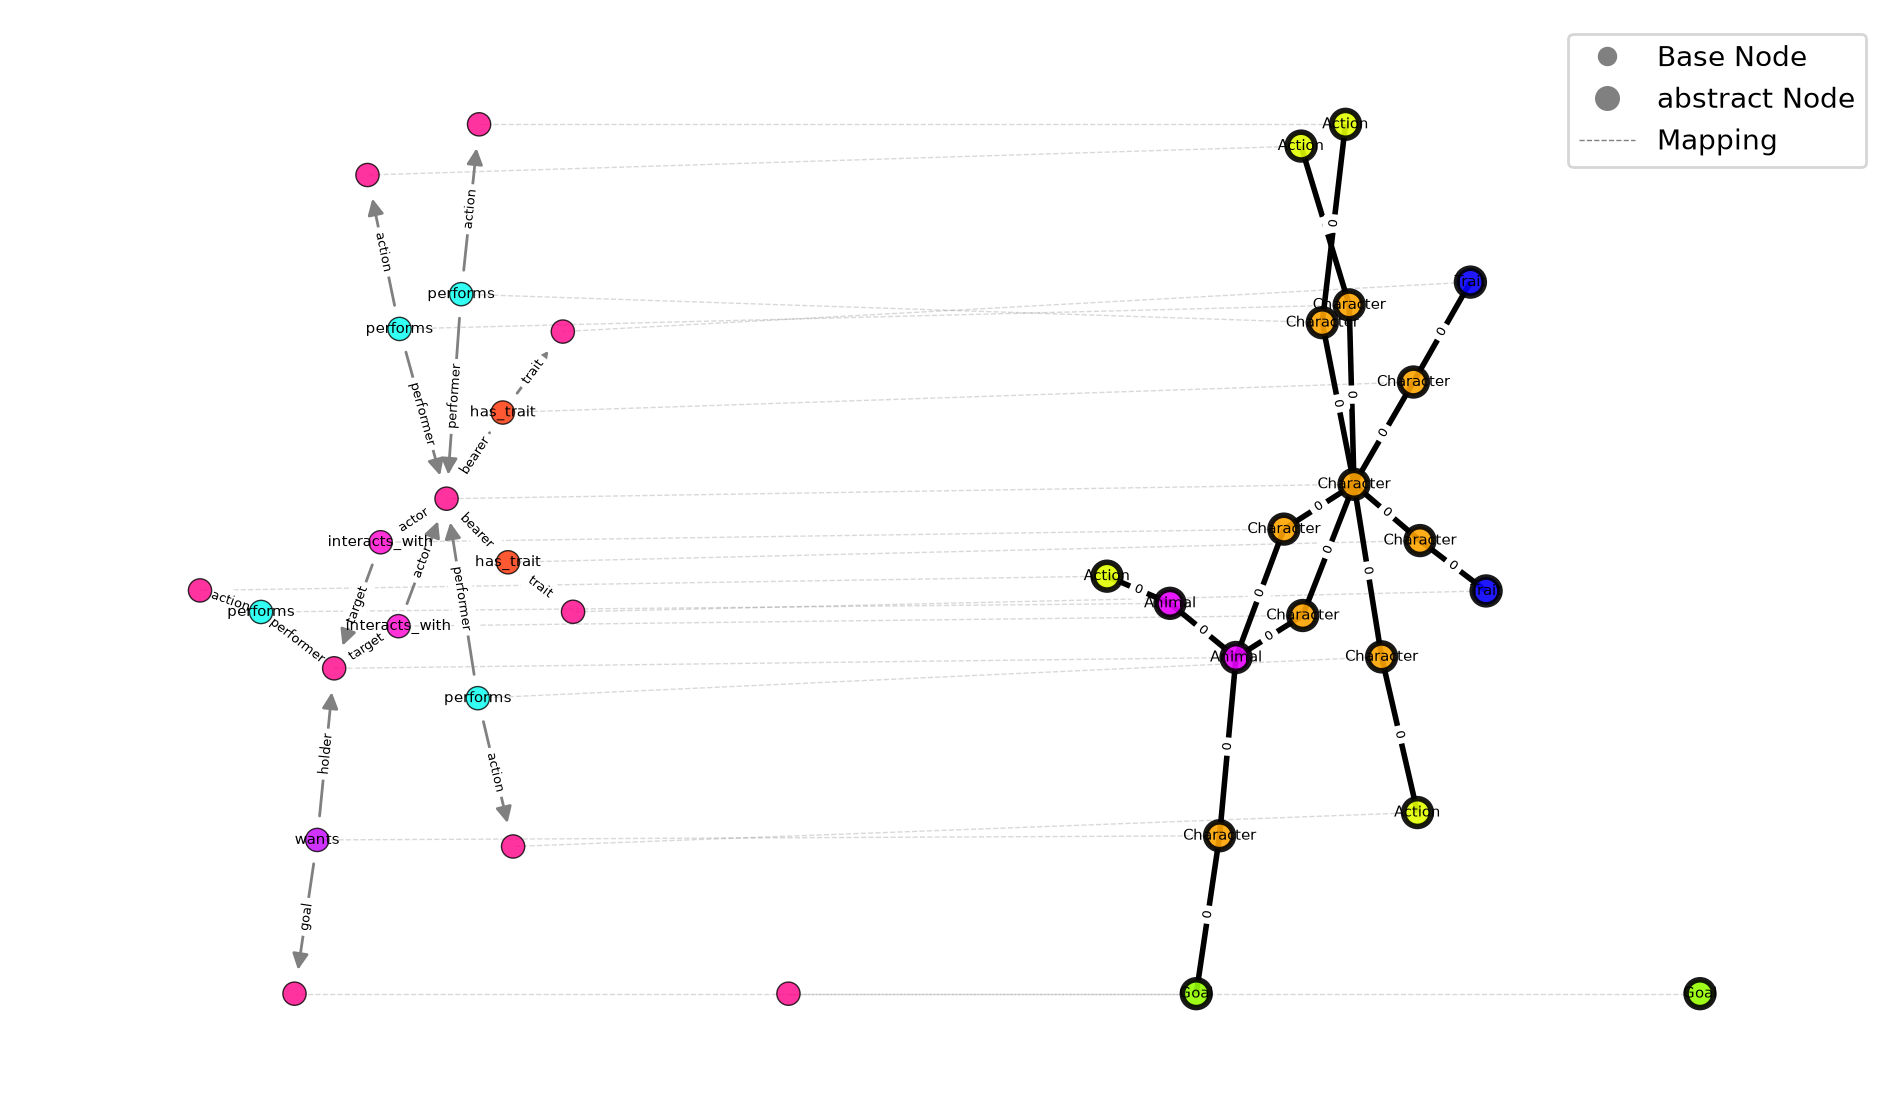

In [7]:
from abstractgraph import display as display_abstract_graph

abstract_graph = graphicalizer.to_abstract_graph(
    graphs[0],
    interpretation_mode="per_entity",
    preserve_direction=True,
    embed_nodes=True,
    parallel_edge_policy="first",
)

from abstractgraph.operators import *
abstract_graph = intersection_edges(abstract_graph, accept_connection_by_edge=True)
display_abstract_graph(
    abstract_graph,
    size=(12, 7),
    show_legend=True,
    node_labels=True,
    node_label_attr="label",
    node_label_font_size=5.5,
    edge_labels=True,
    edge_label_font_size=4.5,
    undirected_layout=True,
)